# DLAM Single-Subject Alignment

Focused diagnostics notebook for one representative DLAM subject (default: median DLAM performance).

This notebook defaults to full-fit diagnostics with lightweight caching enabled.


In [54]:
from pathlib import Path
import sys
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [55]:
# Reload modules so edits are picked up after kernel restarts / file changes
import importlib
import src.eval_utils.results_eda as results_eda
import src.eval_utils.dlam_diagnostics as dlam_diag

importlib.reload(results_eda)
importlib.reload(dlam_diag)

from src.eval_utils.results_eda import (
    EDAConfig,
    prepare_pre_post_harmonization,
    plot_subject_prepost_heatmaps,
    plot_single_subject_scatter_triplet,
    select_subject_by_model,
)
from src.eval_utils.dlam_diagnostics import (
    DlamDiagnosticsConfig,
    compute_dlam_loro_fold_metrics,
    diagnostics_summary_table,
    fit_dlam_subject_diagnostics,
    plot_dlam_bases_panel,
    plot_subject_ahba_harmonized_heatmaps,
    set_academic_style,
)

print('Reloaded:', results_eda.__file__)
print('Reloaded:', dlam_diag.__file__)


Reloaded: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py
Reloaded: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/dlam_diagnostics.py


In [56]:
set_academic_style()

EDA_CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam_dynamicrank',
)

DLAM_CFG = DlamDiagnosticsConfig(
    csv_path=EDA_CFG.csv_path,
    hvg_path=EDA_CFG.hvg_path,
    cache_root=EDA_CFG.cache_root,
    gene_scope=EDA_CFG.gene_scope,
    min_observed_parcels=EDA_CFG.min_observed_parcels,
    combat_use_covariates=EDA_CFG.combat_use_covariates,
    dlam_cache_dirname=EDA_CFG.dlam_cache_dirname,
)

AXIS_X = 'y'
AXIS_Y = 'z'
SUBJECT_MODE = 'median'
FULL_BRAIN_REF = True
RUN_LORO = False
FORCE_REFIT_FULL = False

# Development cache controls
DLAM_CFG.use_diagnostics_cache = True
DLAM_CFG.write_diagnostics_cache = True

EDA_CFG, DLAM_CFG


(EDAConfig(csv_path='data/raw/gxp_samples.csv', hvg_path='data/raw/ahba_100hvg.txt', cache_root='out/loro_subject_cache', naive_cache_dirname='naive', dlam_cache_dirname='dlam', plam_cache_dirname='plam_dynamicrank', gene_scope='allgenes', min_observed_parcels=5, combat_use_covariates=True),
 DlamDiagnosticsConfig(csv_path='data/raw/gxp_samples.csv', hvg_path='data/raw/ahba_100hvg.txt', cache_root='out/loro_subject_cache', gene_scope='allgenes', min_observed_parcels=5, combat_use_covariates=True, dlam_cache_dirname='dlam', n_comp_target=3, ridge_alpha_bridge=0.01, rbf_smoothing=0.1, gp_length_scale=25.0, seed=123, c_min=4, basis_model='affine_gl3', strategy='constrained_anchor', spatial_method='rbf', diagnostics_cache_root='out/dlam_diagnostics', use_diagnostics_cache=True, write_diagnostics_cache=True))

dlam_steps.png


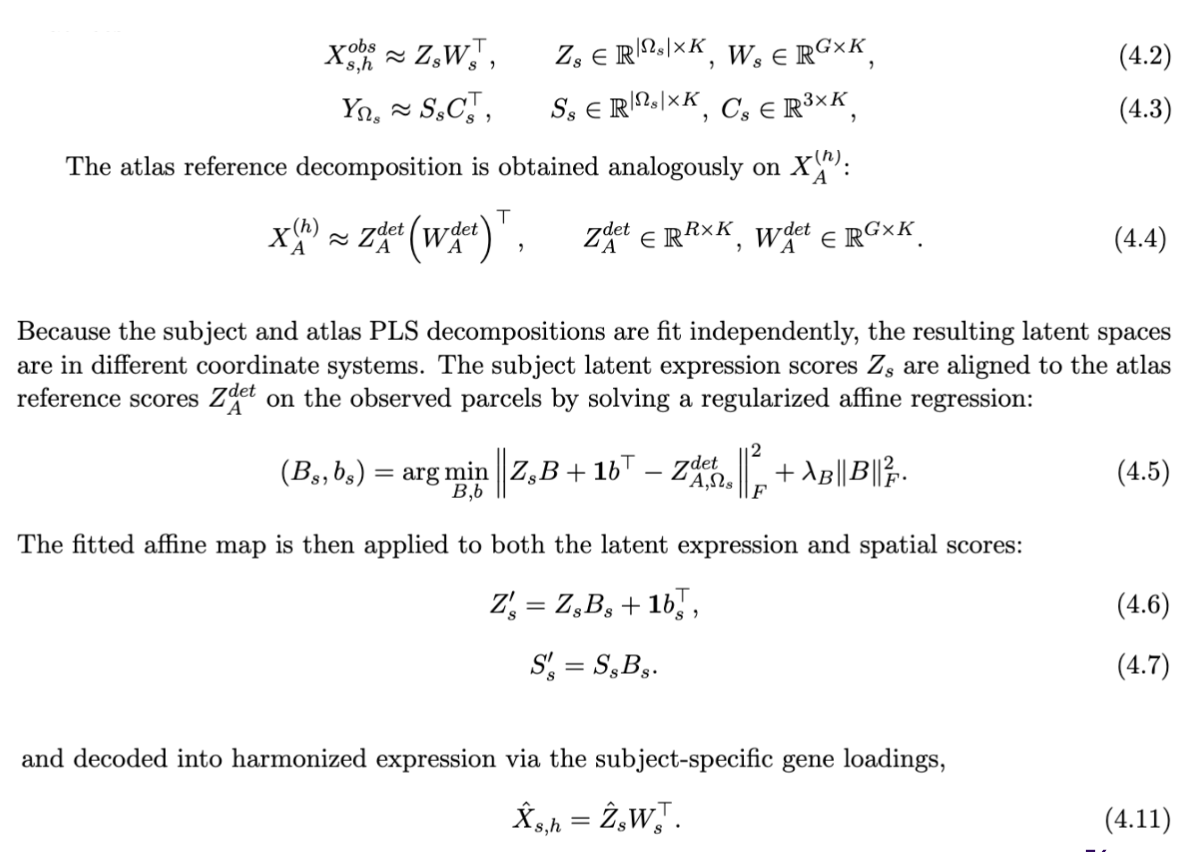

dlam_bases.jpg


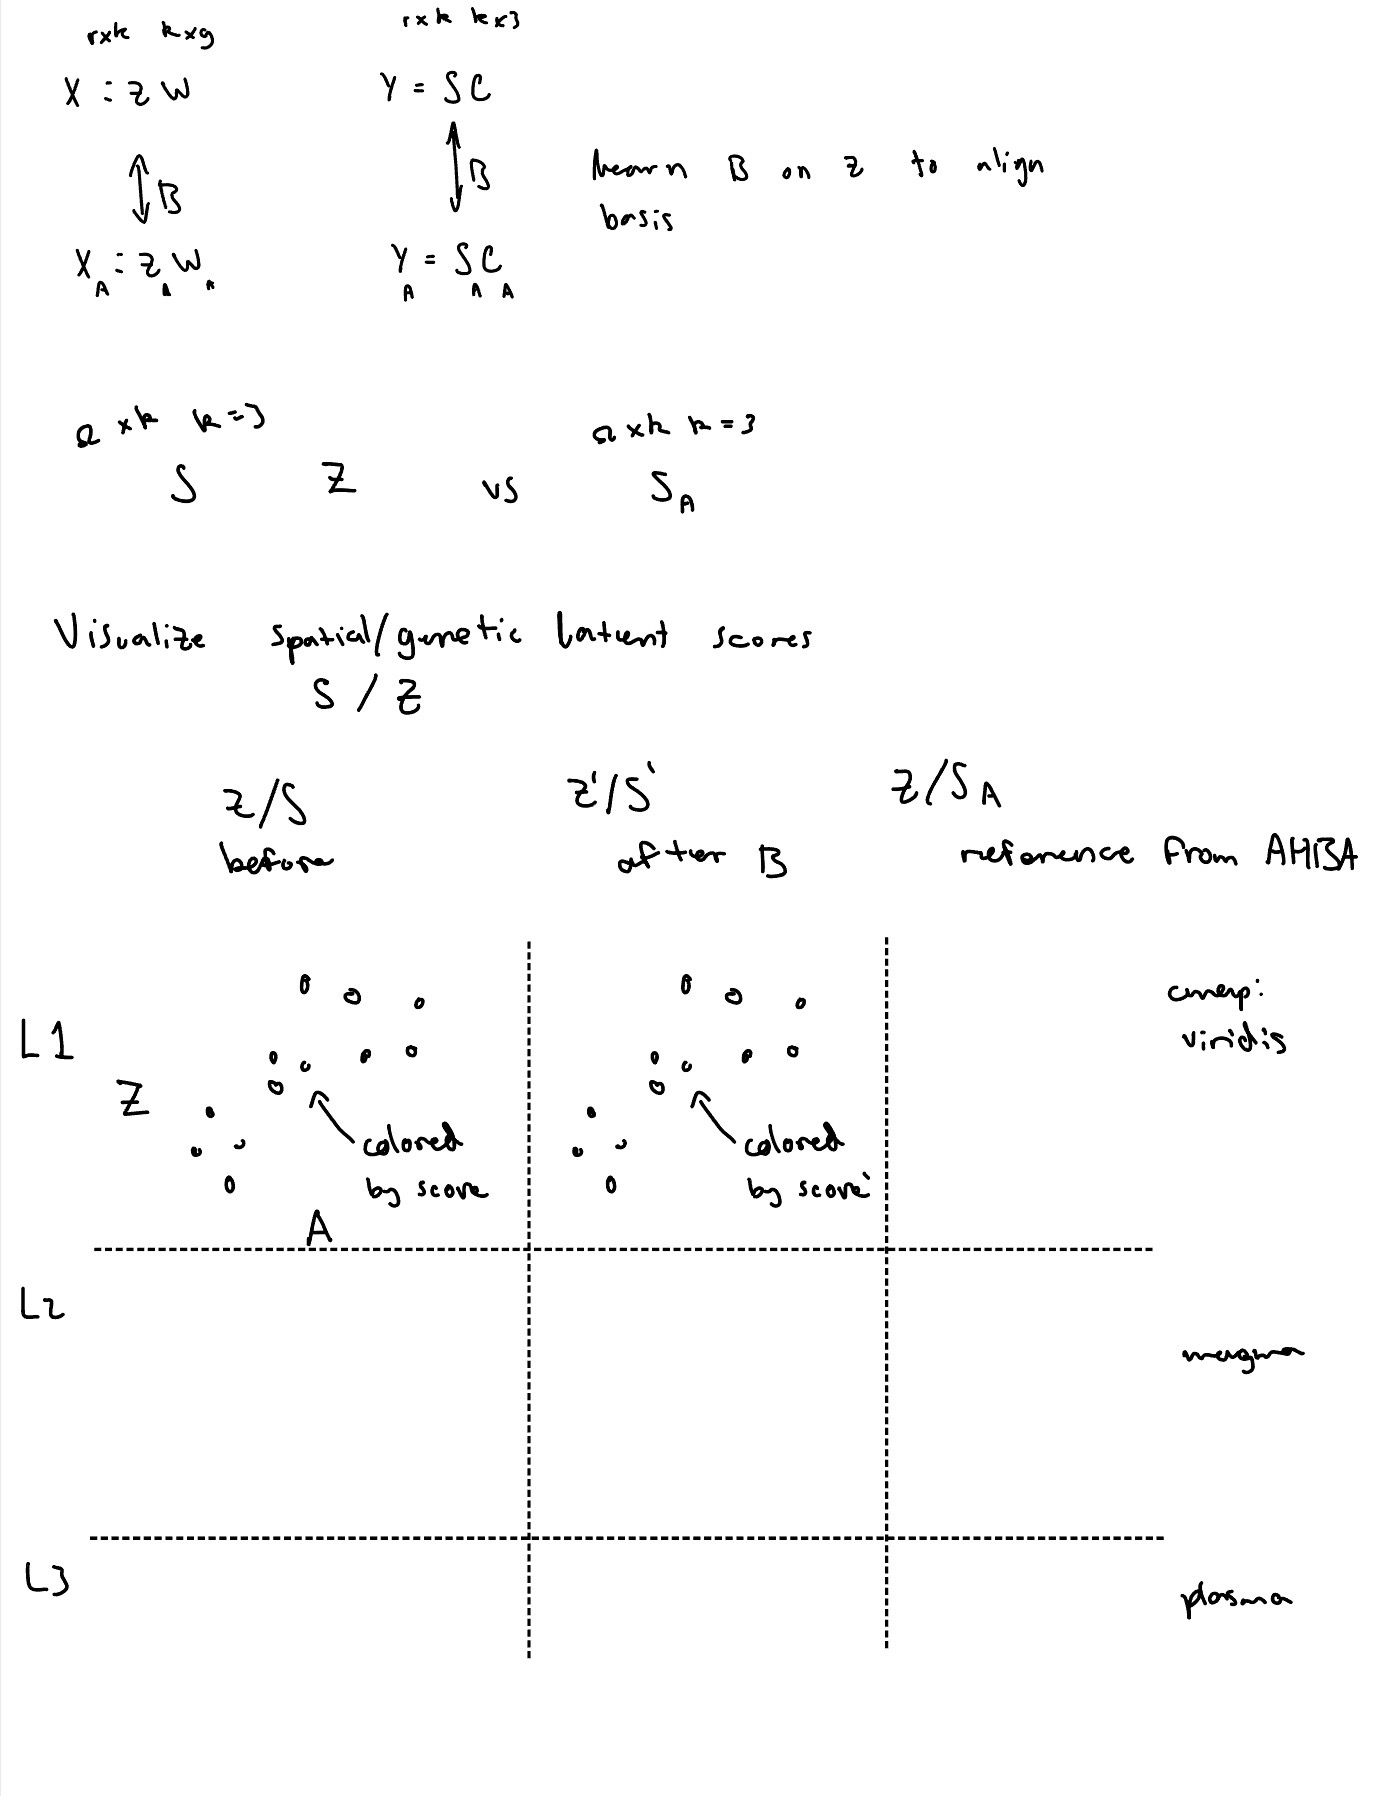

vogel_gradient.png


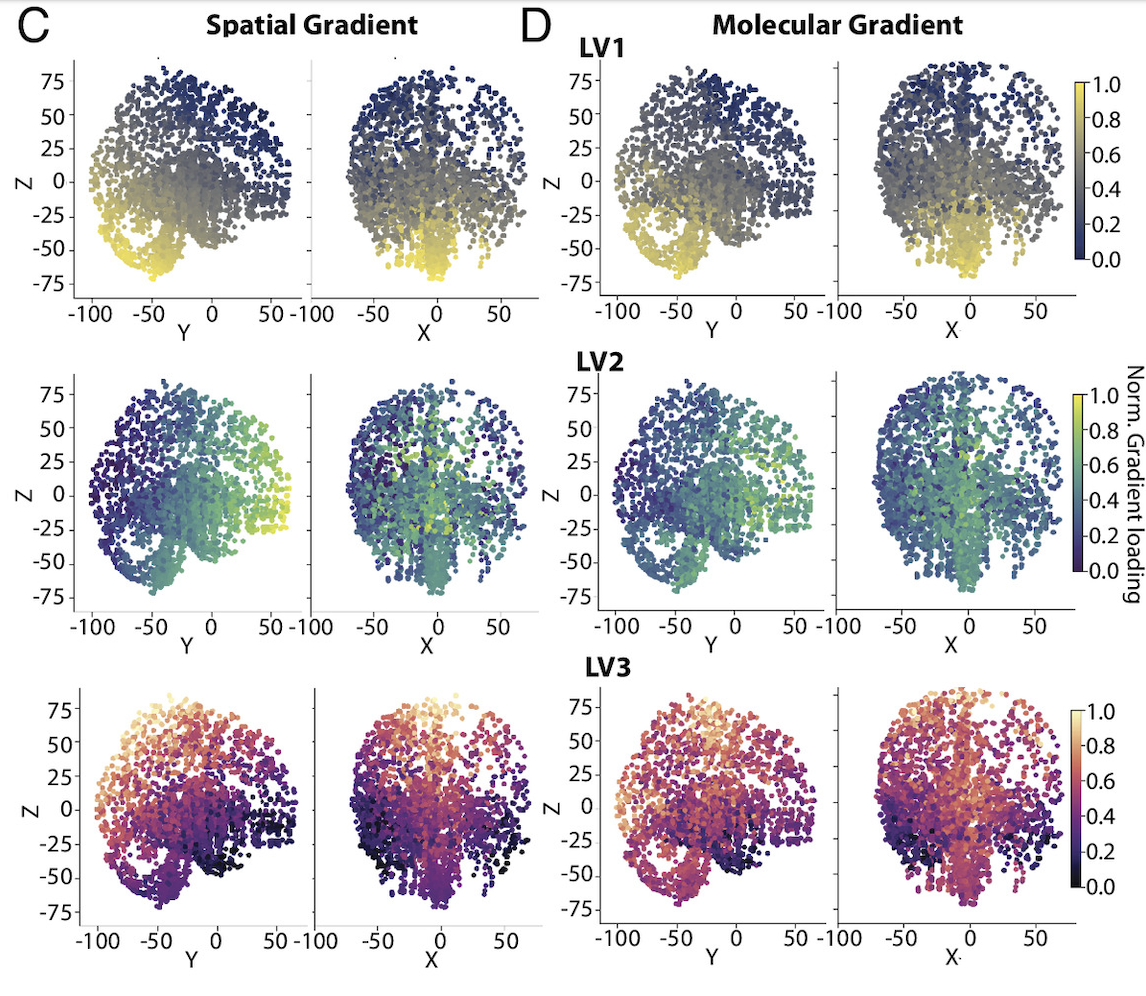

In [37]:
for p in [
    REPO_ROOT / 'context_packages/dlam_steps.png',
    REPO_ROOT / 'context_packages/dlam_bases.jpg',
    REPO_ROOT / 'context_packages/vogel_gradient.png',
]:
    if p.exists():
        print(p.name)
        display(Image(filename=str(p), width=520))


In [38]:
SUBJECT_ID = select_subject_by_model(EDA_CFG, mode=SUBJECT_MODE, metric='pearson_r', model='dlam')
print('subject:', SUBJECT_ID)
PREPOST = prepare_pre_post_harmonization(EDA_CFG)
print('eligible subjects:', len(PREPOST['subjects']))


subject: GTEX-11GS4
eligible subjects: 313


## Subject Harmonization Views


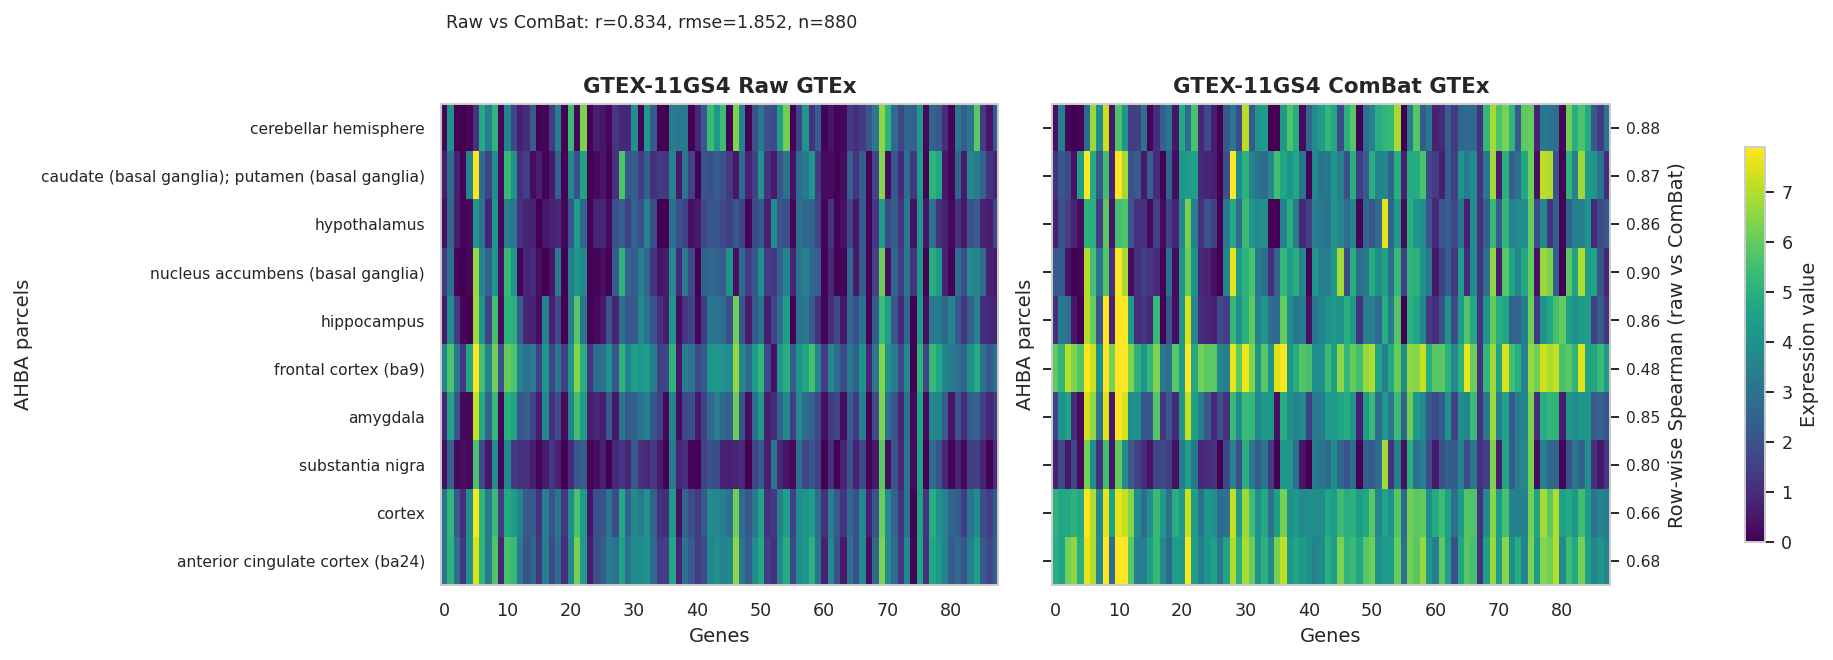

In [39]:
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode='hvg',
    observed_only=True,
    label_mode='gtex',
    label_stride=1,
)


scatter subject: GTEX-11GS4


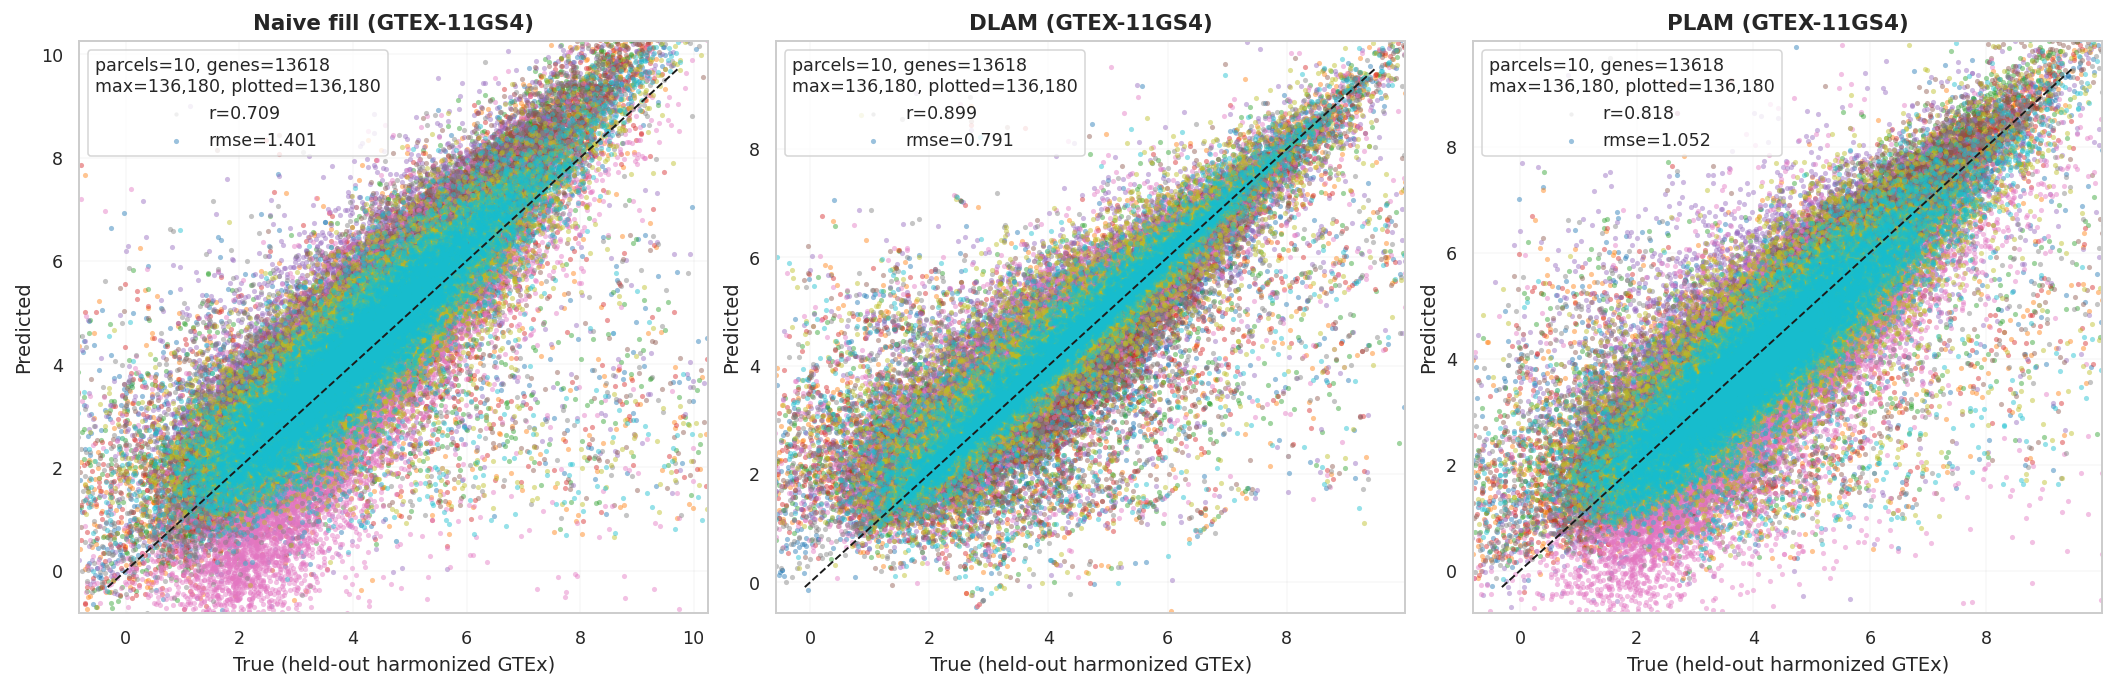

In [40]:
fig, axes, sid = plot_single_subject_scatter_triplet(
    EDA_CFG,
    subject_id=SUBJECT_ID,
    rank_model='dlam',
    color_by='parcel',
    top_n=10,
)
print('scatter subject:', sid)


## DLAM Full-Fit Diagnostics


In [57]:
if FORCE_REFIT_FULL:
    old = DLAM_CFG.use_diagnostics_cache
    DLAM_CFG.use_diagnostics_cache = False
    diag_full = fit_dlam_subject_diagnostics(
        DLAM_CFG,
        subject_id=SUBJECT_ID,
        fold_mode='full',
    )
    DLAM_CFG.use_diagnostics_cache = old
else:
    diag_full = fit_dlam_subject_diagnostics(
        DLAM_CFG,
        subject_id=SUBJECT_ID,
        fold_mode='full',
    )
diagnostics_summary_table(diag_full)


,subject,fold_mode,hold_parcel,fold_selector,n_obs,n_train,n_comp,basis_model,hold_pearson,hold_rmse,hold_n_points
0,GTEX-11GS4,full,-1,,10,10,3,affine_gl3,NaN,NaN,0


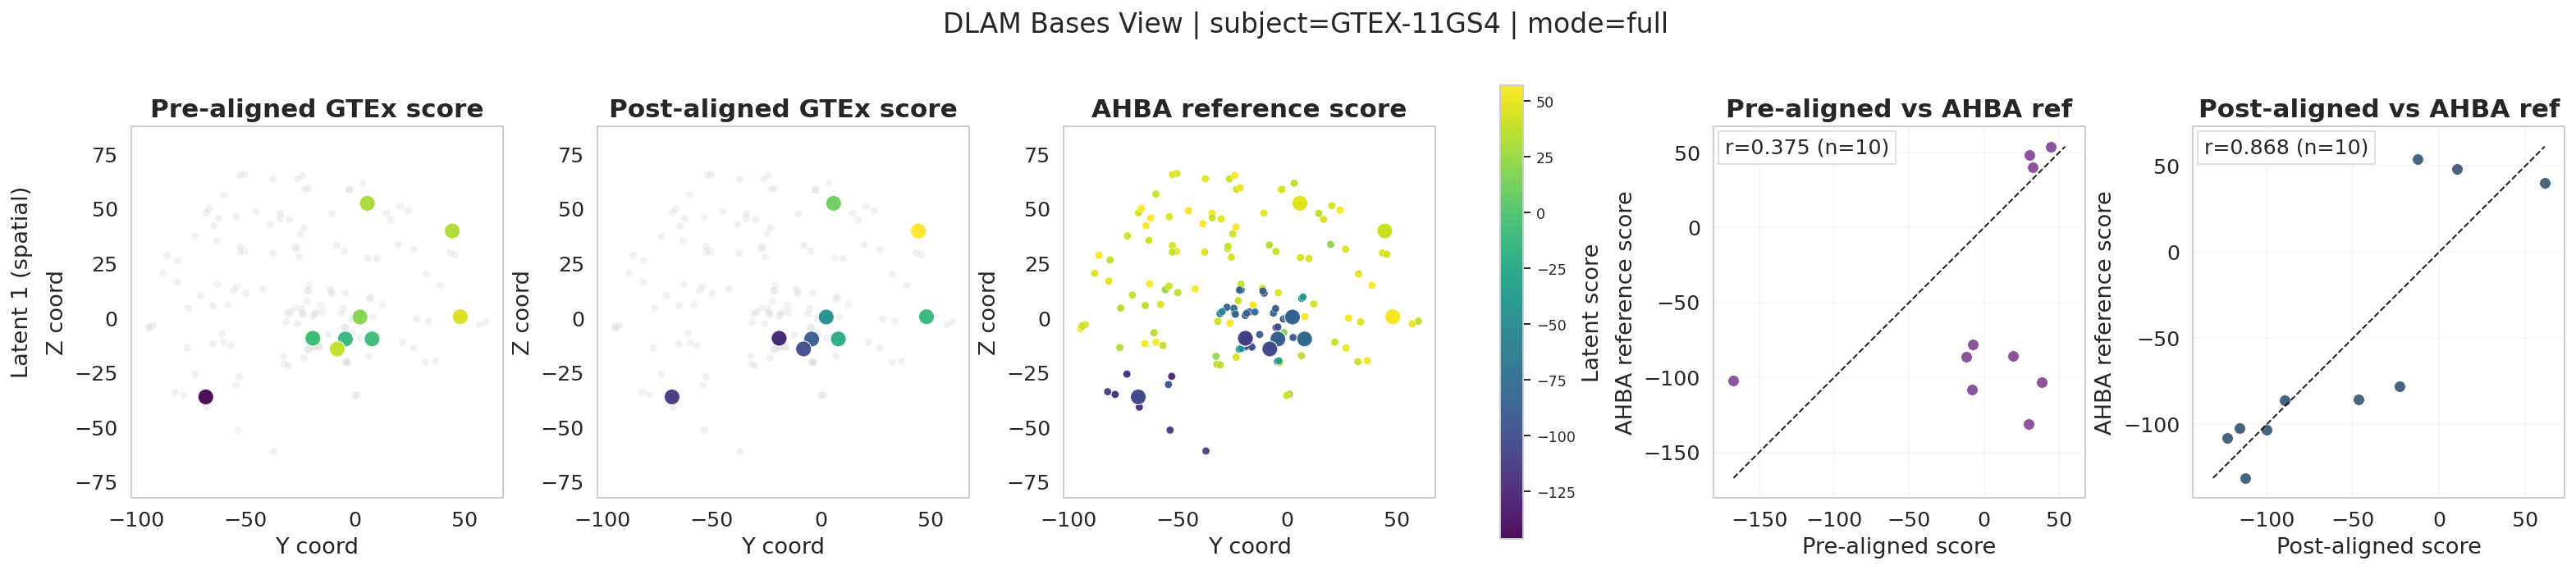

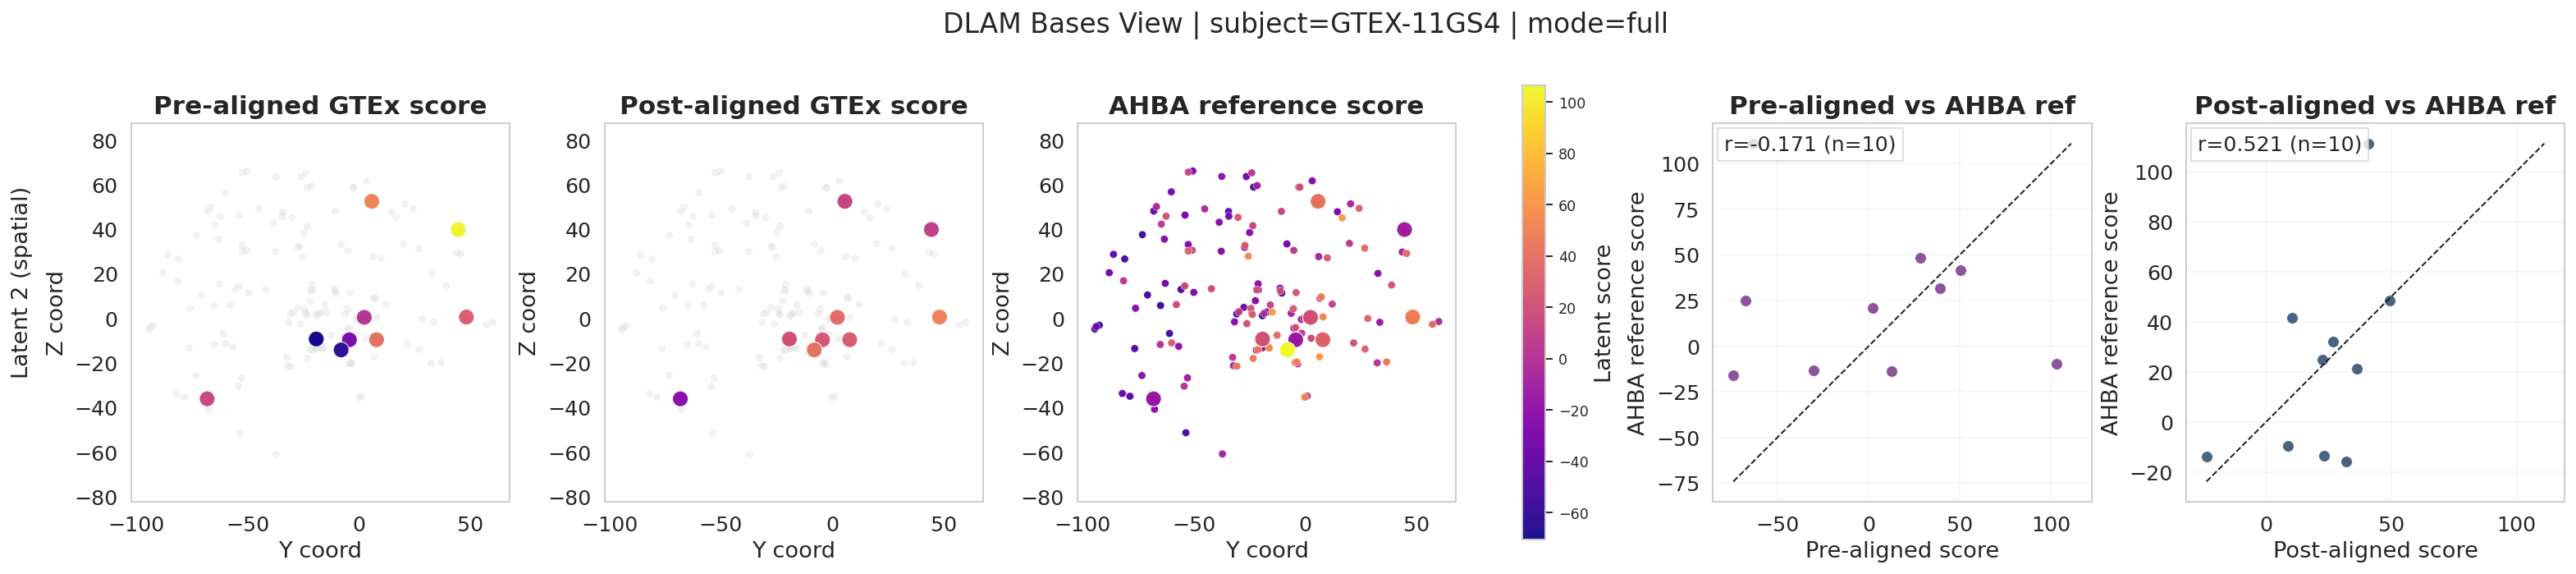

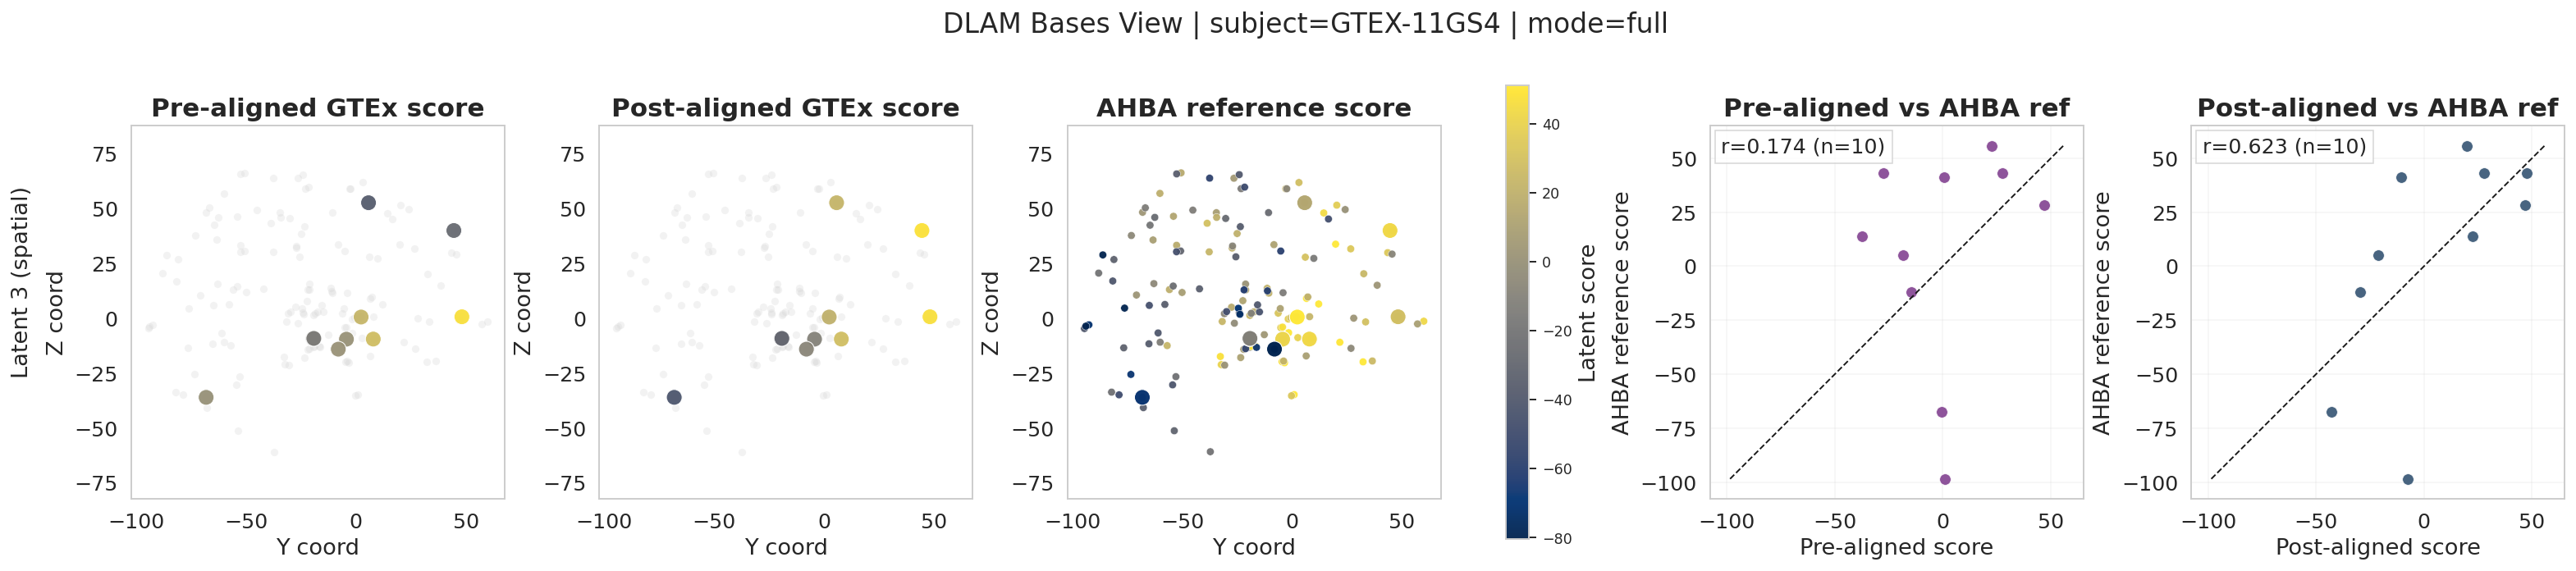

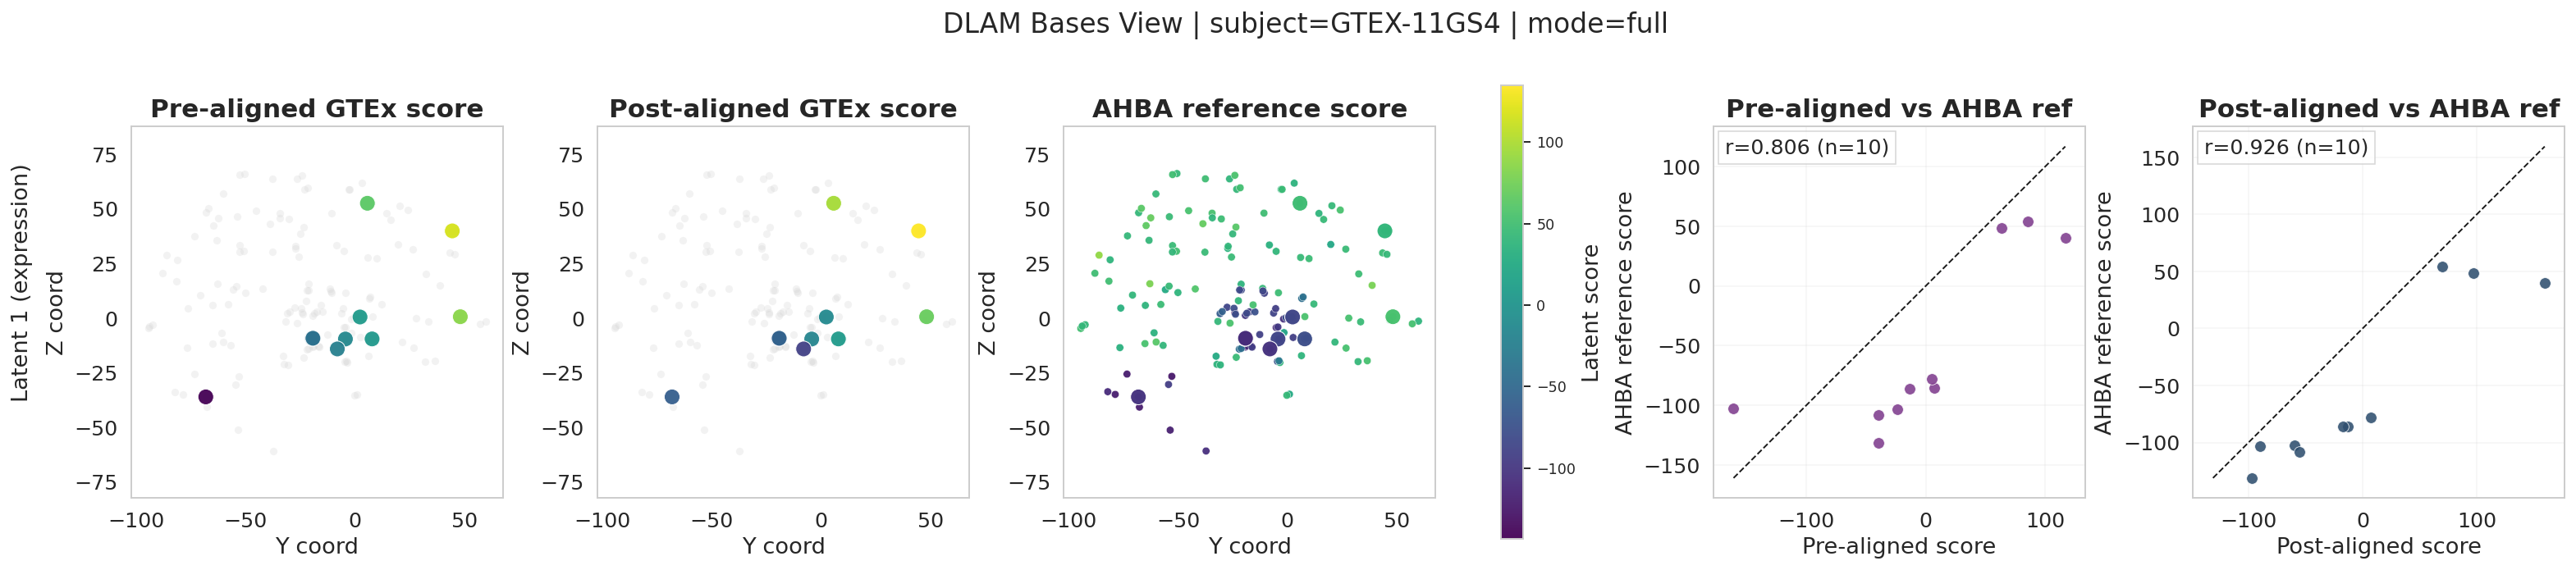

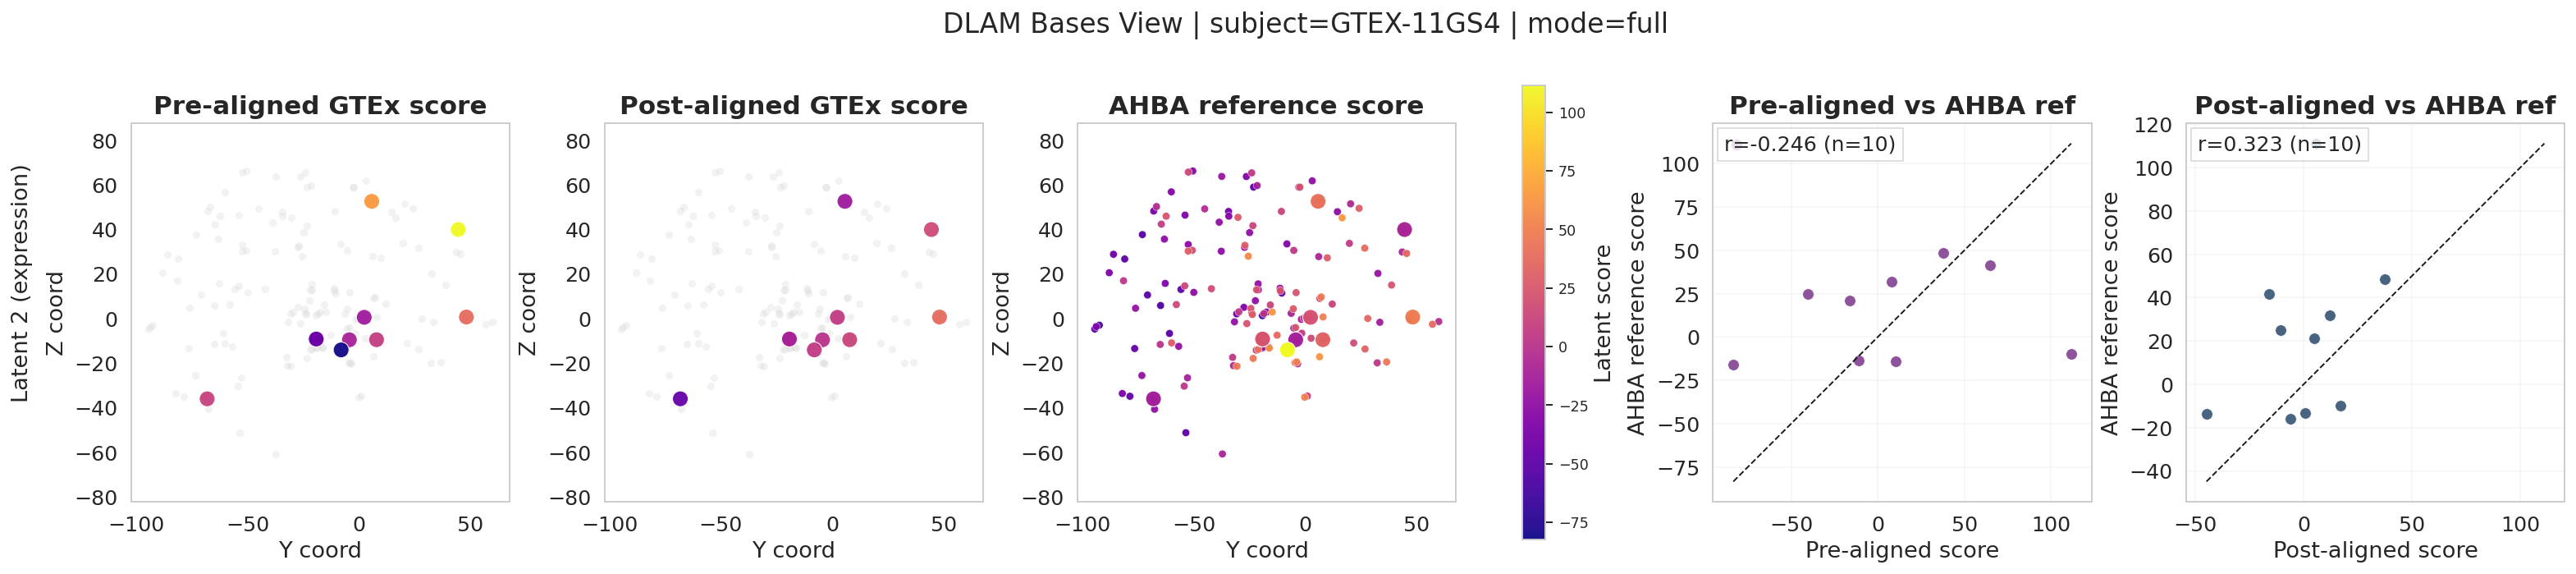

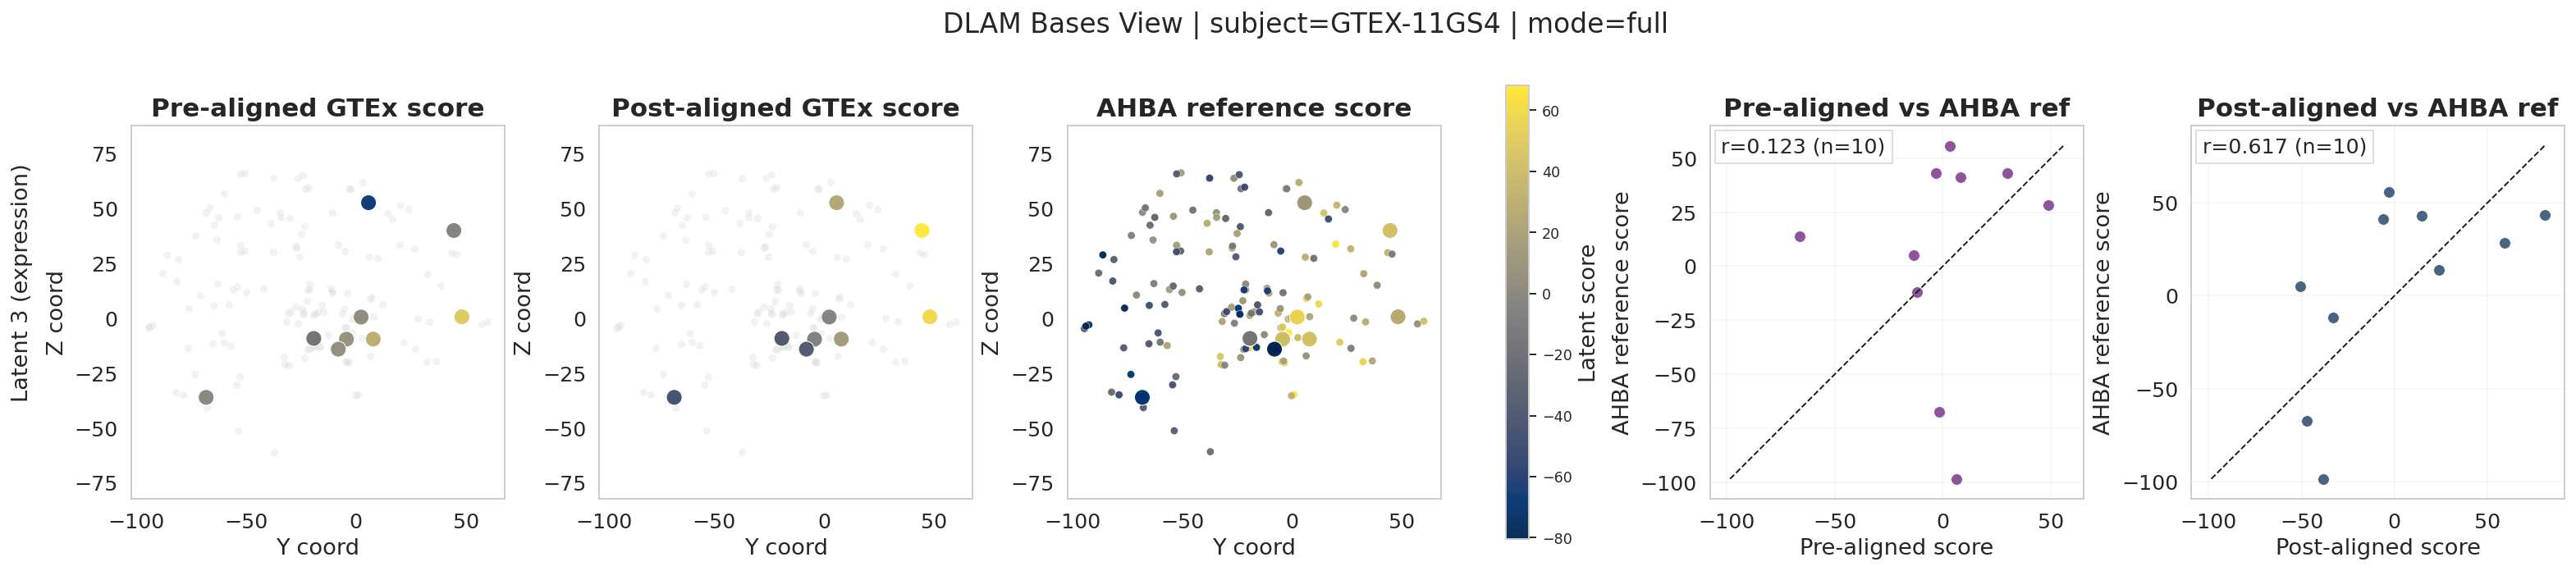

In [58]:
for component in [0, 1, 2]:
    fig, axes = plot_dlam_bases_panel(
        diag_full,
        component=component,
        axis_x=AXIS_X,
        axis_y=AXIS_Y,
        full_brain_ref=FULL_BRAIN_REF,
        latent_space='spatial'
    )

for component in [0, 1, 2]:
    fig, axes = plot_dlam_bases_panel(
        diag_full,
        component=component,
        axis_x=AXIS_X,
        axis_y=AXIS_Y,
        full_brain_ref=FULL_BRAIN_REF,
        latent_space='expression'
    )


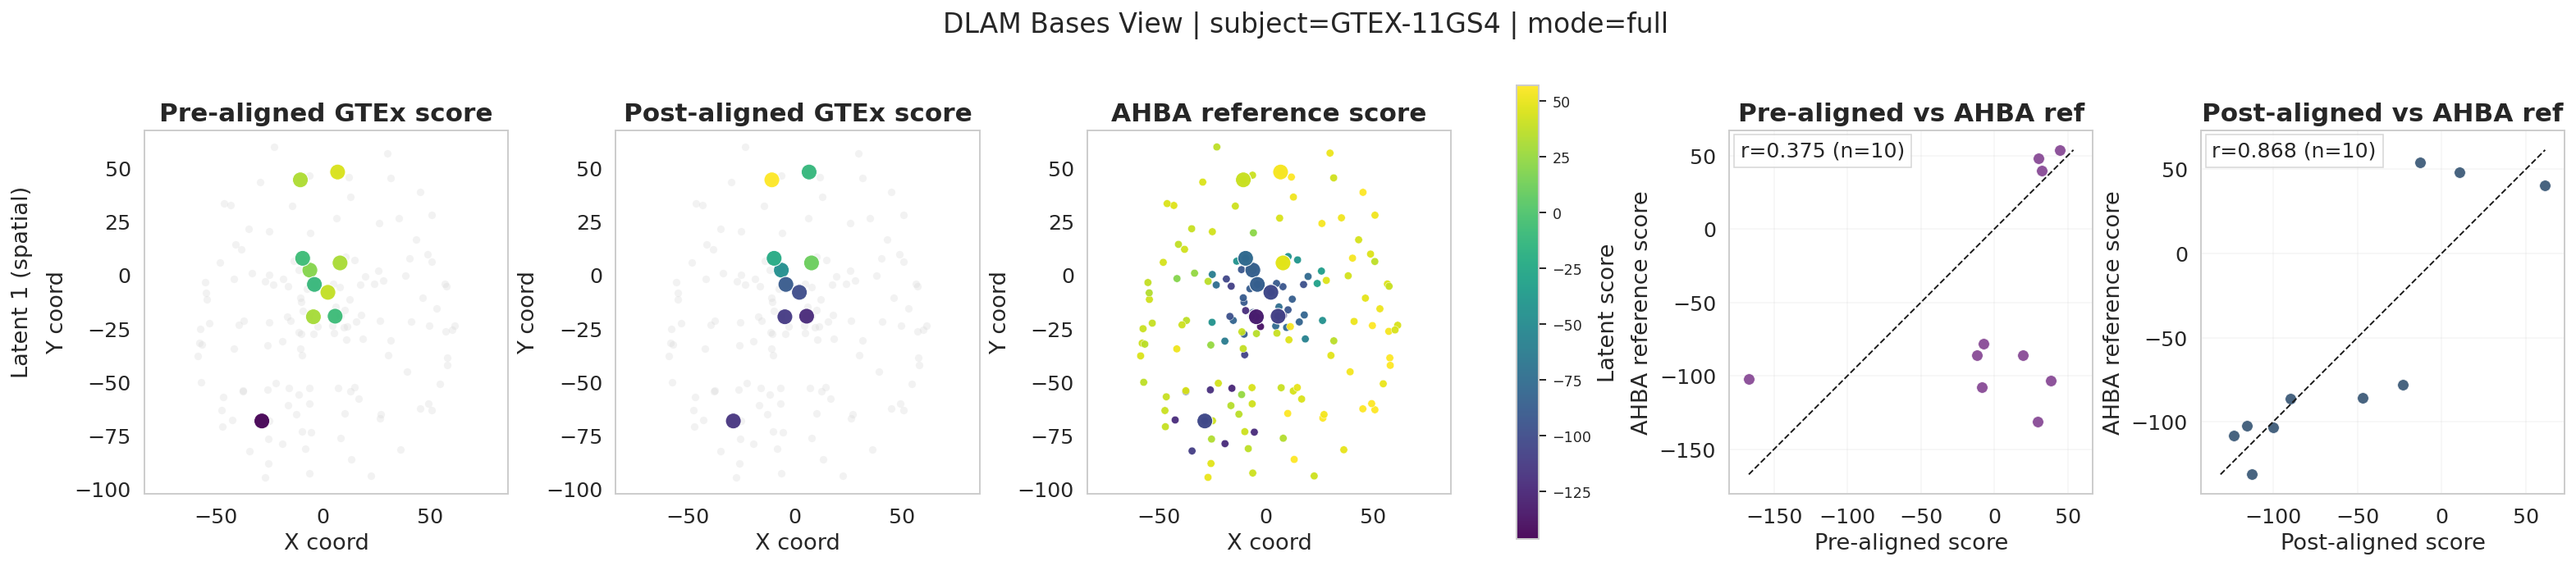

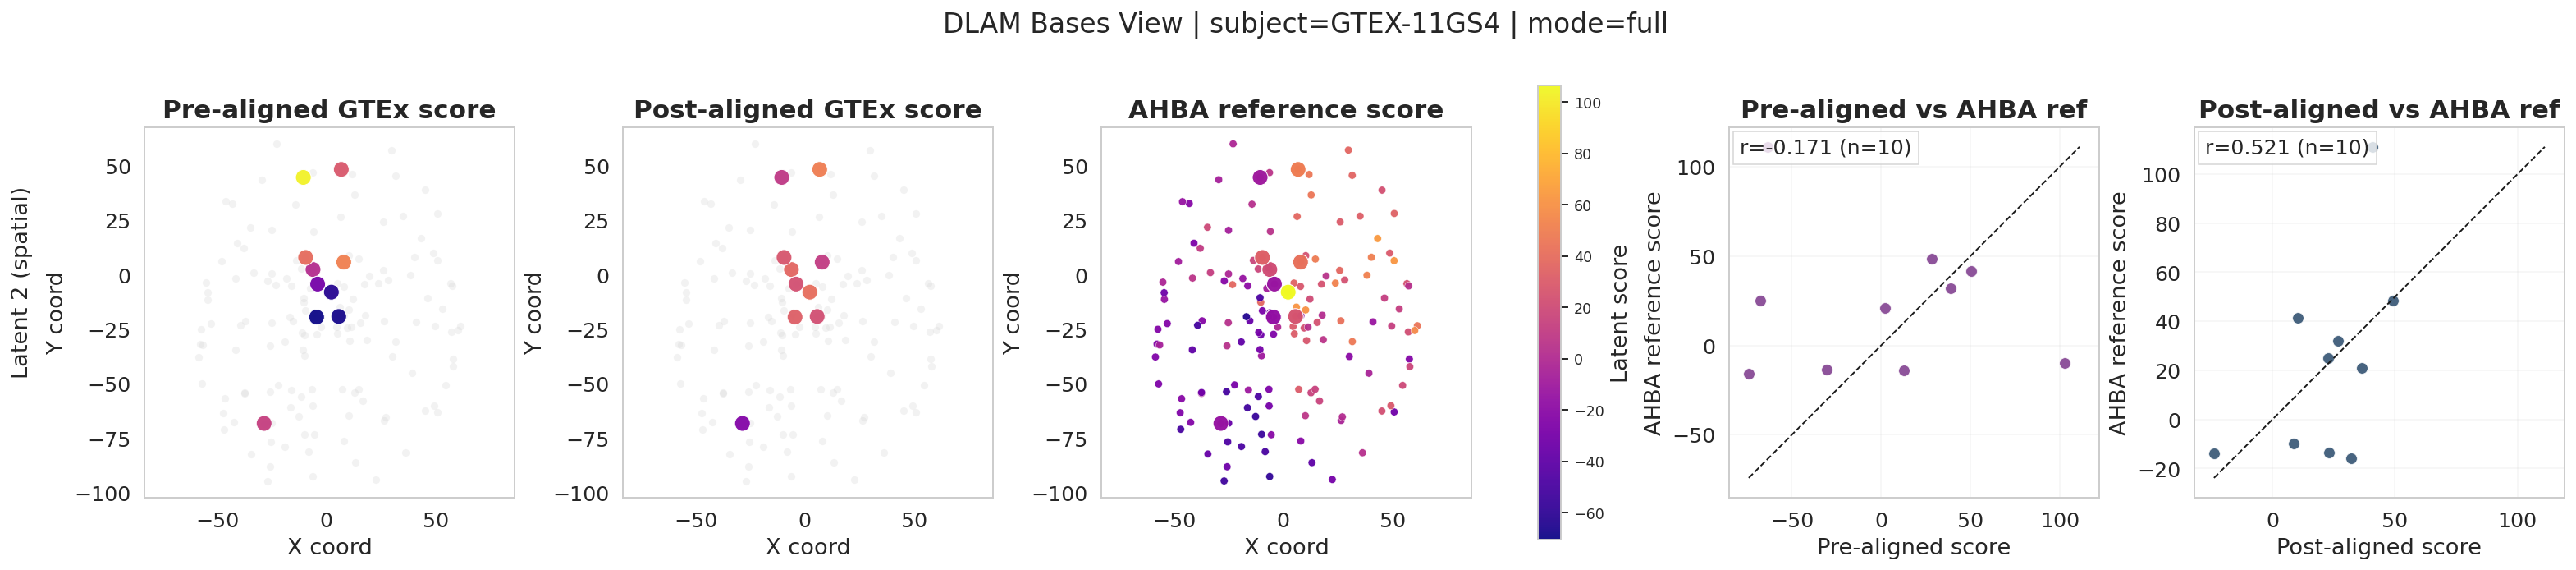

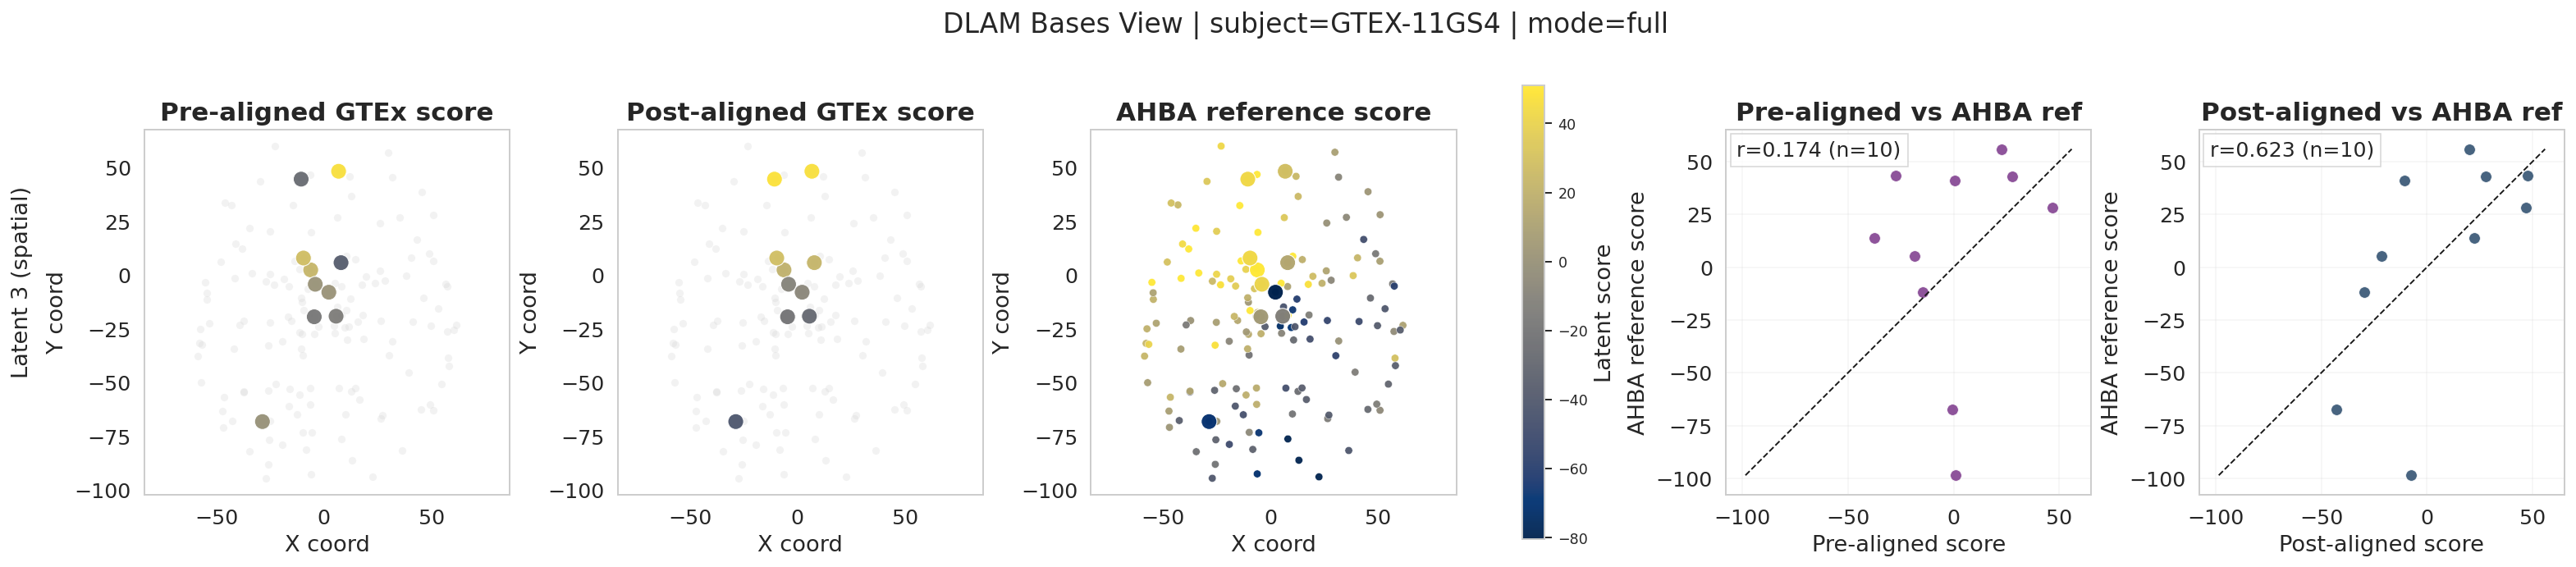

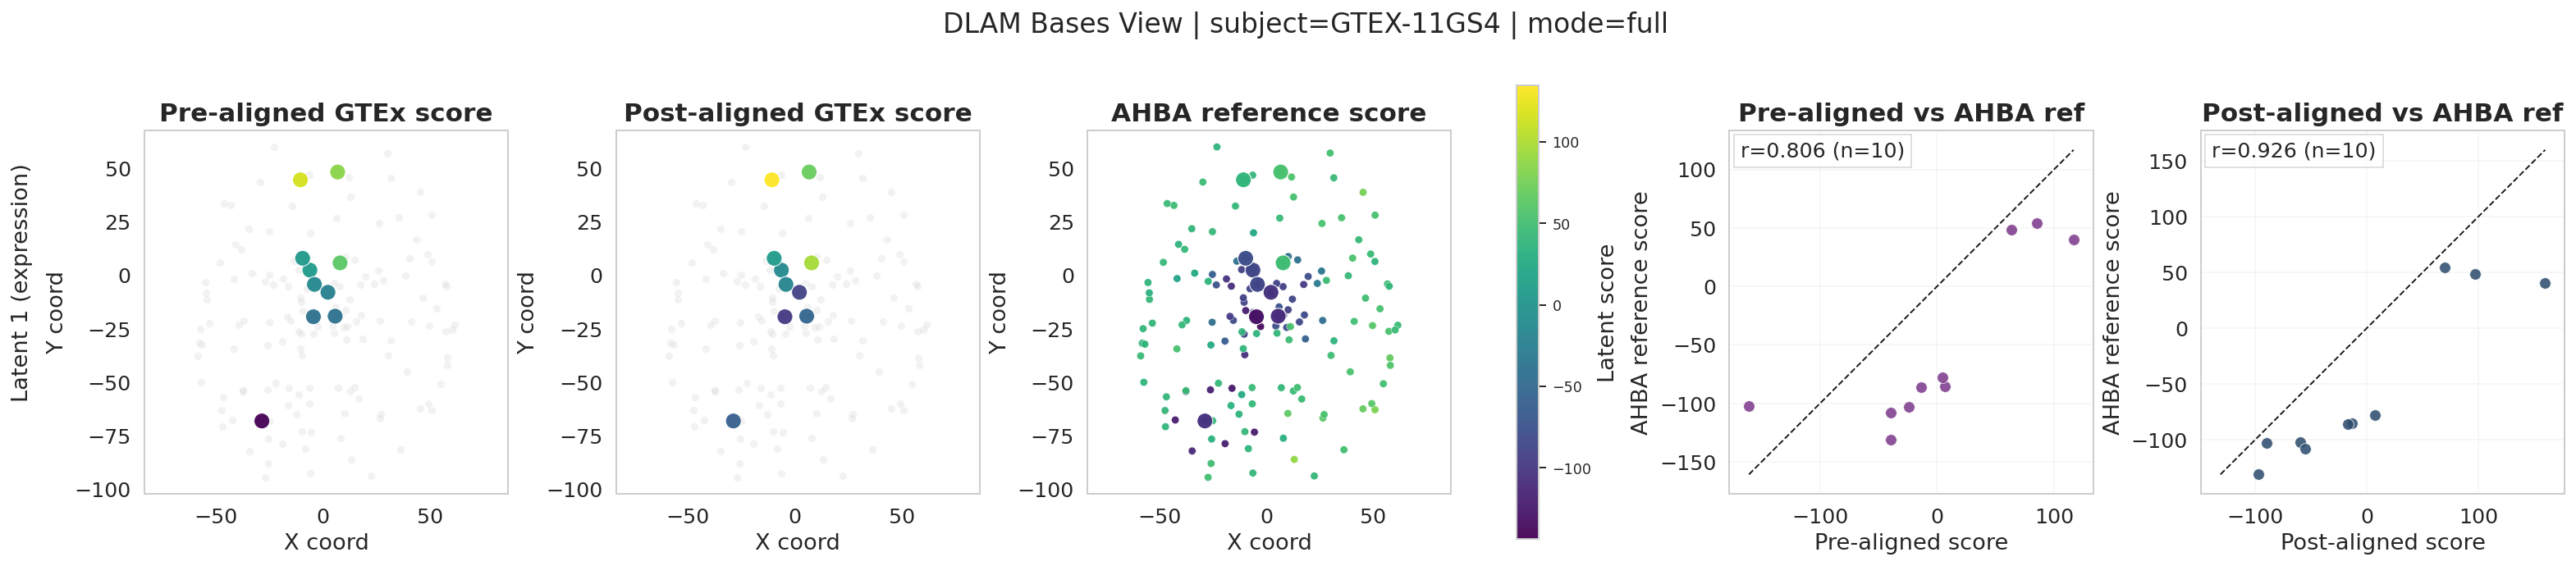

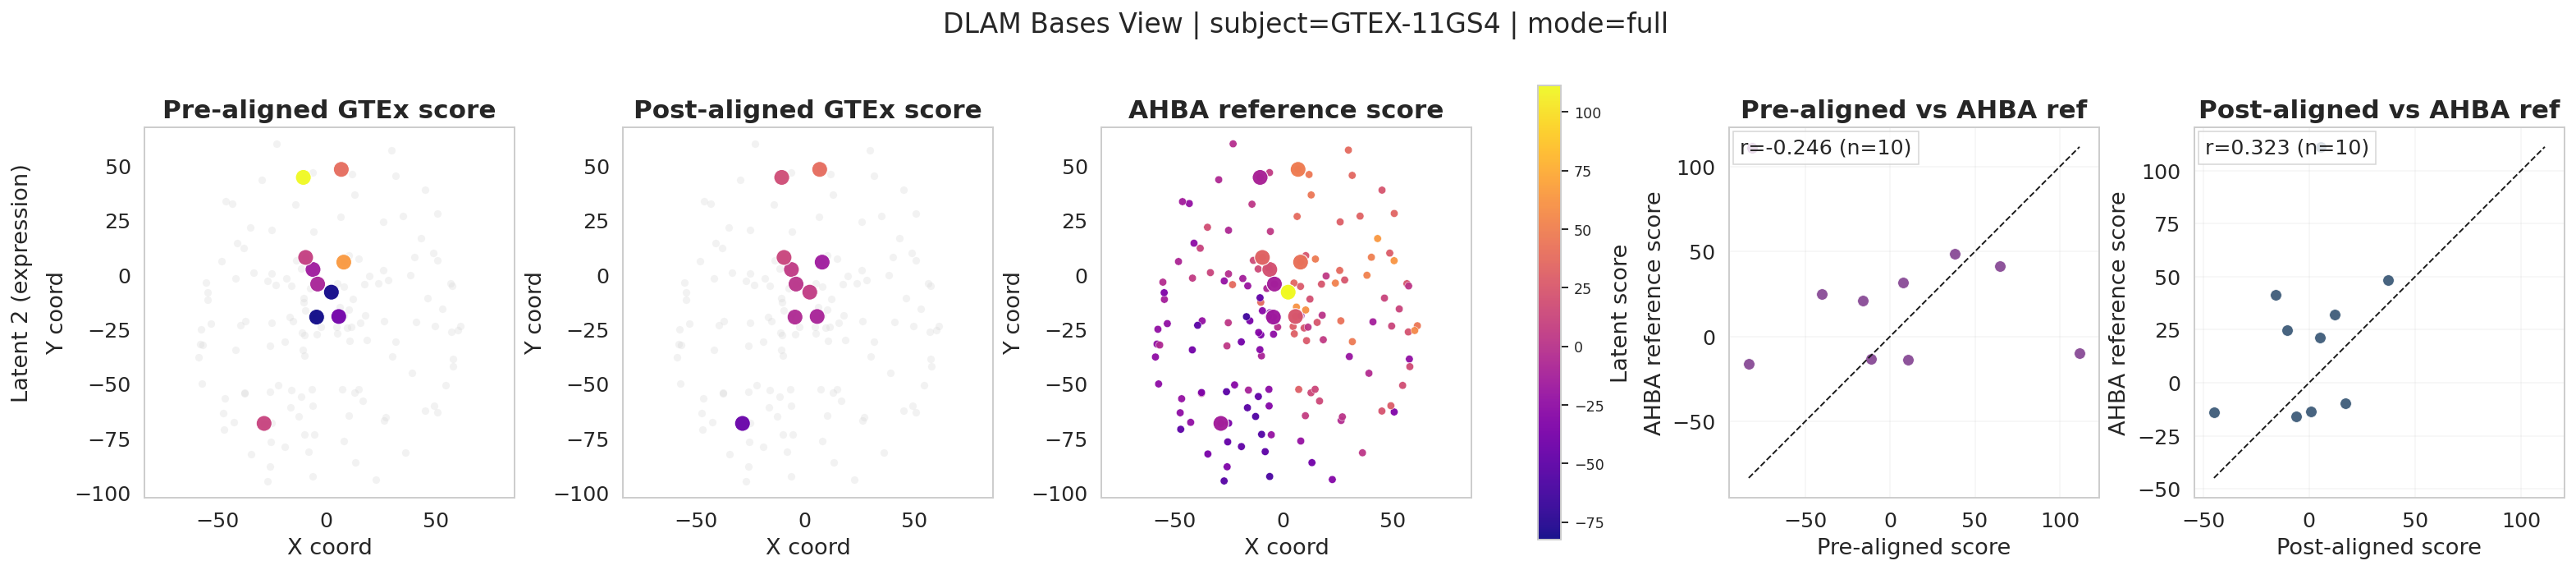

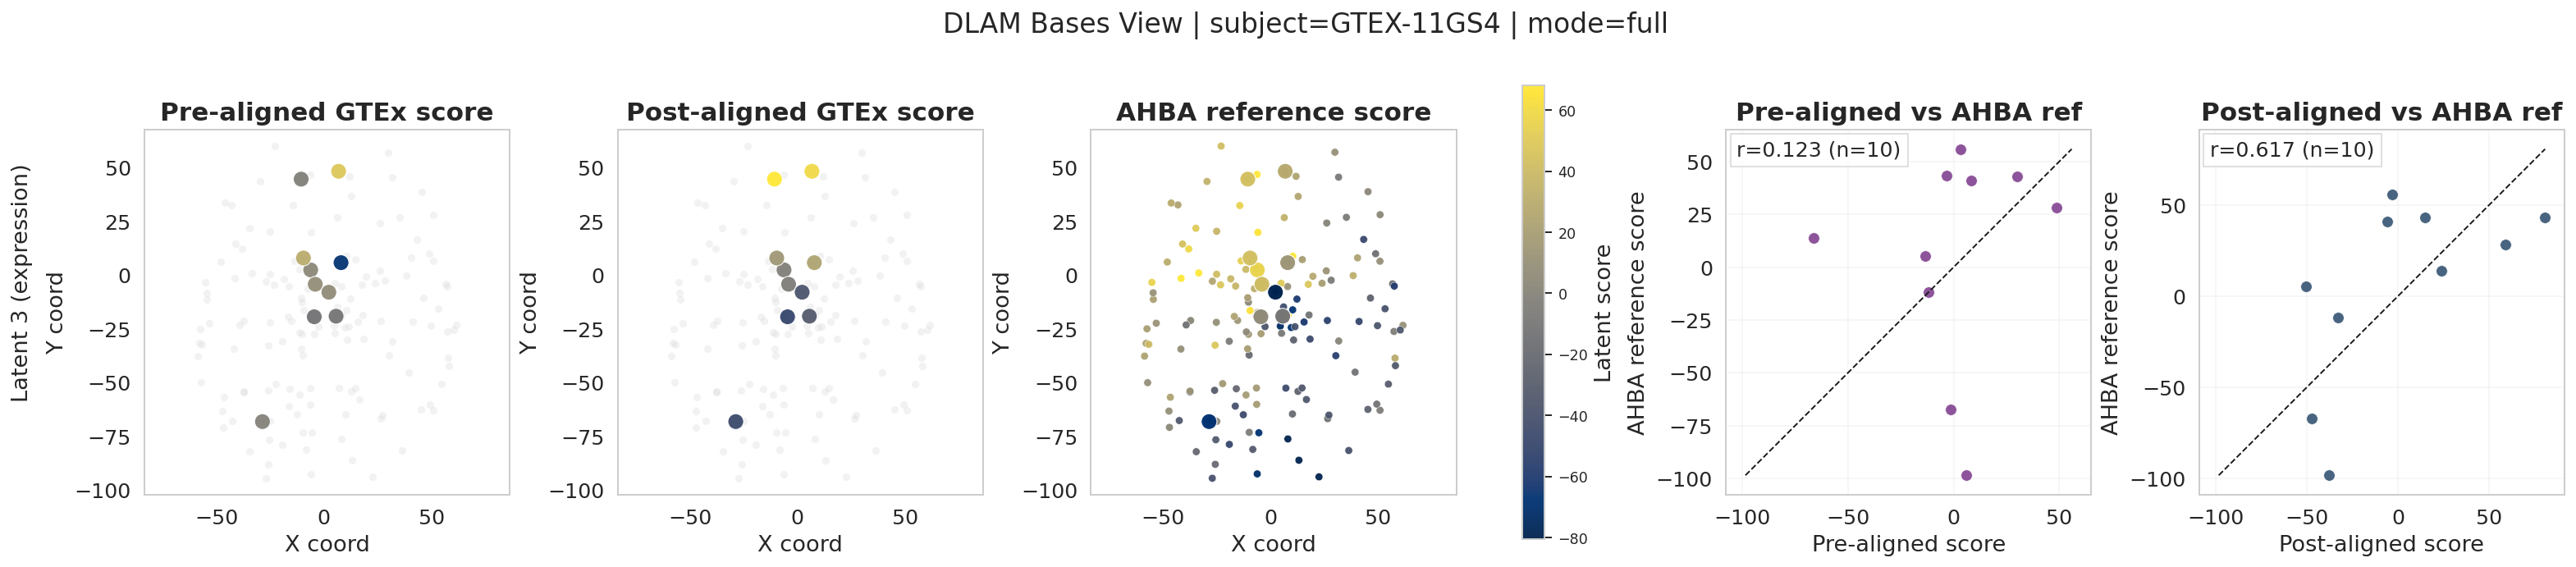

In [60]:
for component in [0, 1, 2]:
    fig, axes = plot_dlam_bases_panel(
        diag_full,
        component=component,
        axis_x='x',
        axis_y='y',
        full_brain_ref=FULL_BRAIN_REF,
        latent_space='spatial'
    )

for component in [0, 1, 2]:
    fig, axes = plot_dlam_bases_panel(
        diag_full,
        component=component,
        axis_x='x',
        axis_y='y',
        full_brain_ref=FULL_BRAIN_REF,
        latent_space='expression'
    )


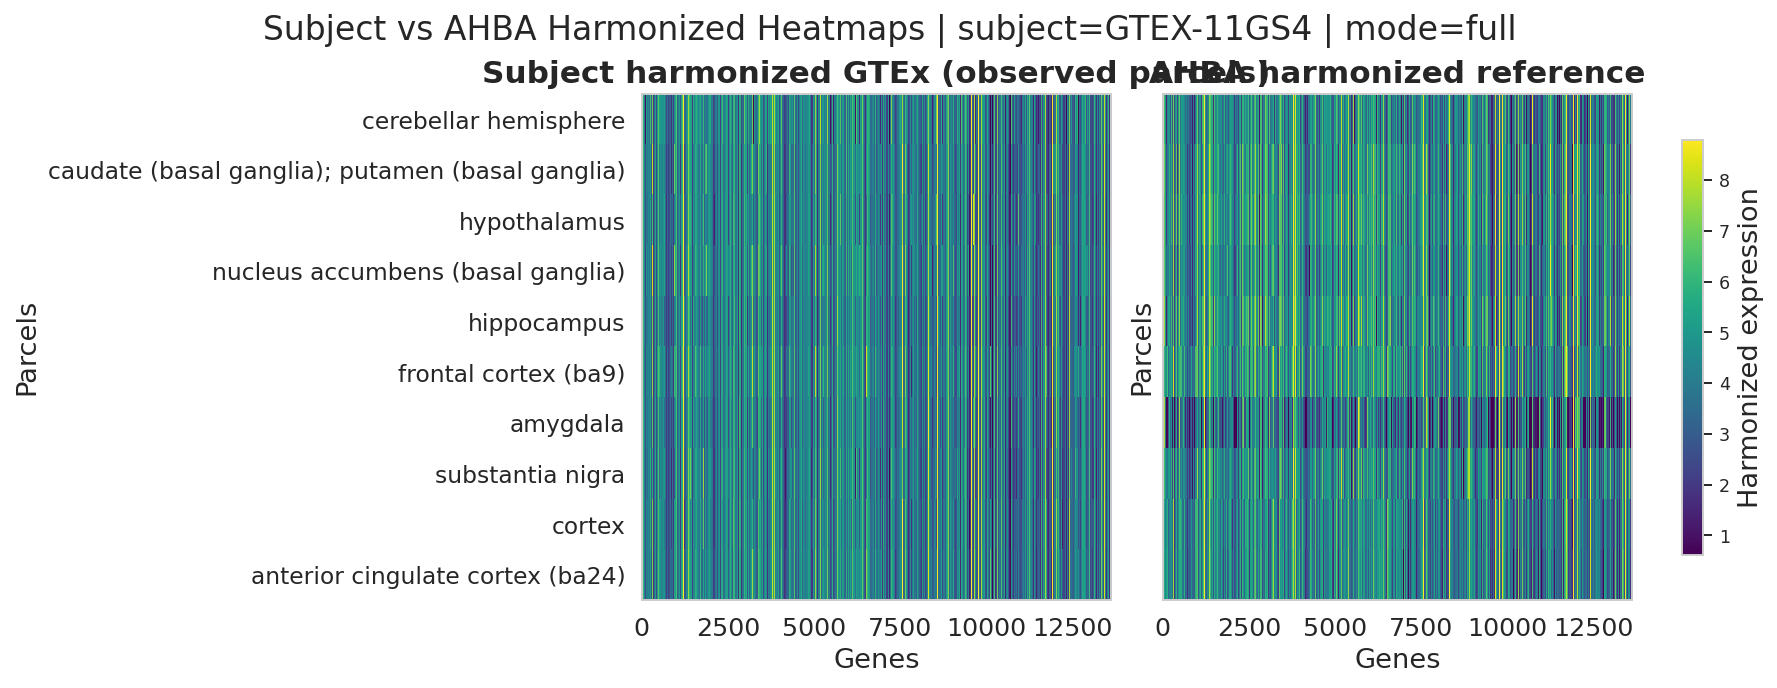

In [43]:
fig, axes = plot_subject_ahba_harmonized_heatmaps(
    diag_full,
    observed_only=True,
    label_mode='gtex',
    label_stride=1,
)


## Optional: DLAM LORO Fold Diagnostics

This block is gated by `RUN_LORO`.


In [44]:
if RUN_LORO:
    fold_df = compute_dlam_loro_fold_metrics(DLAM_CFG, SUBJECT_ID)
    display(fold_df)
else:
    print('RUN_LORO=False: skipping optional LORO diagnostics block.')


RUN_LORO=False: skipping optional LORO diagnostics block.


In [45]:
if RUN_LORO:
    diag_loro = fit_dlam_subject_diagnostics(
        DLAM_CFG,
        subject_id=SUBJECT_ID,
        fold_mode='loro',
        hold_selector='median_rmse',
    )
    display(diagnostics_summary_table(diag_loro))
else:
    print('RUN_LORO=False: skipping optional LORO diagnostics block.')


RUN_LORO=False: skipping optional LORO diagnostics block.


In [46]:
if RUN_LORO:
    for component in [0, 1, 2]:
        fig, axes = plot_dlam_bases_panel(
            diag_loro,
            component=component,
            axis_x=AXIS_X,
            axis_y=AXIS_Y,
            full_brain_ref=FULL_BRAIN_REF,
        )
else:
    print('RUN_LORO=False: skipping optional LORO diagnostics block.')


RUN_LORO=False: skipping optional LORO diagnostics block.
